In [7]:
#cell 1

from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


project_root = Path.cwd()

if project_root.name == "notebooks":
    project_root = project_root.parent

data_path = (
    project_root
    / "data"
    / "processed"
    / "nhanes_2017_2018.csv"
)

data = pd.read_csv(data_path)

print("Dataset shape:", data.shape)
data.head()

Dataset shape: (5261, 11)


,SEQN,age,sex_code,race_ethnicity_code,sample_weight,survey_cluster,survey_stratum,bmi,waist_cm,a1c,elevated_a1c
0,93705.0,66.0,2.0,4.0,8338.419786,2.0,145.0,31.7,101.8,6.2,1
1,93706.0,18.0,1.0,6.0,8723.439814,2.0,134.0,21.5,79.3,5.2,0
2,93708.0,66.0,2.0,6.0,14372.488765,2.0,138.0,23.7,88.2,6.2,1
3,93709.0,75.0,2.0,4.0,12277.556662,1.0,136.0,38.9,113.0,6.3,1
4,93711.0,56.0,1.0,6.0,12390.919724,2.0,134.0,21.3,86.6,5.7,1


In [8]:
#cell 2

missing_percentages = (
    data.isna()
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
)

missing_percentages

waist_cm               5.34
bmi                    1.63
SEQN                   0.00
sex_code               0.00
age                    0.00
race_ethnicity_code    0.00
sample_weight          0.00
survey_stratum         0.00
survey_cluster         0.00
a1c                    0.00
elevated_a1c           0.00
dtype: float64

In [9]:
#cell 3

group_comparison = (
    data.groupby("elevated_a1c")[
        ["age", "bmi", "waist_cm", "a1c"]
    ]
    .mean()
    .round(2)
)

group_comparison

,age,bmi,waist_cm,a1c
elevated_a1c,,,,
0,42.95,28.31,95.91,5.27
1,59.07,31.54,105.87,6.57


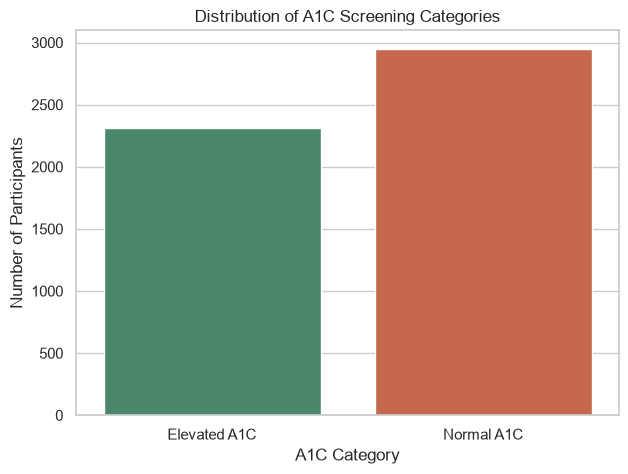

In [10]:
#cell 4

data["a1c_status"] = data["elevated_a1c"].map(
    {
        0: "Normal A1C",
        1: "Elevated A1C"
    }
)

sns.set_theme(style="whitegrid")

plt.figure(figsize=(7, 5))

sns.countplot(
    data=data,
    x="a1c_status",
    hue="a1c_status",
    legend=False,
    palette=["#40916c", "#d95d39"]
)

plt.title("Distribution of A1C Screening Categories")
plt.xlabel("A1C Category")
plt.ylabel("Number of Participants")
plt.show()

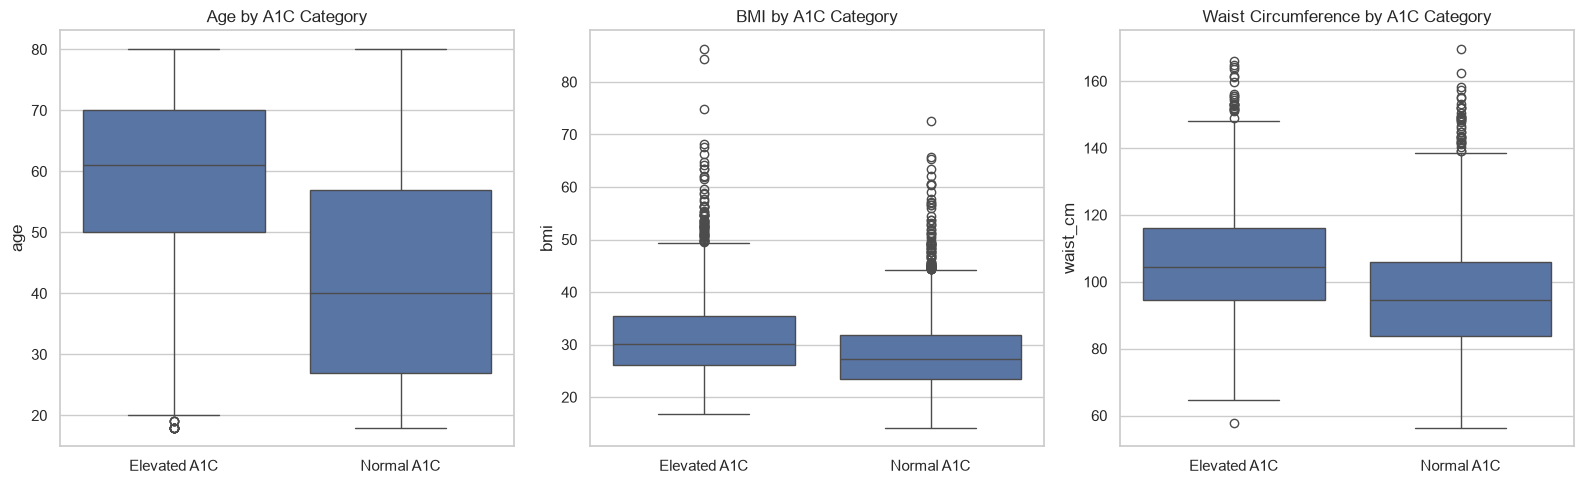

In [14]:
#cell 5

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.boxplot(
    data=data,
    x="a1c_status",
    y="age",
    ax=axes[0]
)

sns.boxplot(
    data=data,
    x="a1c_status",
    y="bmi",
    ax=axes[1]
)

sns.boxplot(
    data=data,
    x="a1c_status",
    y="waist_cm",
    ax=axes[2]
)

axes[0].set_title("Age by A1C Category")
axes[1].set_title("BMI by A1C Category")
axes[2].set_title("Waist Circumference by A1C Category")

for axis in axes:
    axis.set_xlabel("")

plt.tight_layout()
plt.show()